# Task 3 — Step 4: Common Evaluation and Diagnostics (Sketch loaded here only)

ERM (Task 2 Source-only checkpoint), DAN-DG (λ = 1) and SAM (ρ = 0.05) were all fixed in notebooks 1–3 from source-validation macro-F1 alone. This is the **final Task 3 evaluation script**, the first and only place a Sketch image is loaded for Task 3.

Reported for each model:
- accuracy and macro-F1 on each source validation domain, their **mean** and **worst** value;
- Sketch accuracy and macro-F1, and the change in Sketch accuracy relative to ERM;
- **source-domain separability**: frozen features, balanced across the 3 source validation sets, seeded 70/30 split, multinomial logistic regression with C = 1 (chance 33.3%);
- the **common sharpness proxy** $\Delta_{\text{sharp}}=L_{\text{val}}(\theta+\epsilon)-L_{\text{val}}(\theta)$, $\epsilon=0.05\,\nabla_\theta L_{\text{val}}/\|\nabla_\theta L_{\text{val}}\|_2$, on a fixed batch of 32 validation images per source (seed 6304), eval mode;
- per-class Sketch changes vs ERM, dominant confusions, failures, and a comparison with the corresponding Task 2 results (target-aware DAN).

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, torch.nn as nn, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.manifold import TSNE

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import EVAL_TRANSFORM
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show, bar_labels
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import collect_outputs
from task3_domain_generalization.src.train import get_source_loaders
from task3_domain_generalization.src.evaluate import source_separability, fixed_sharpness_batch, sharpness_proxy

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task3_domain_generalization', 'checkpoints')
T2 = os.path.join(ROOT, 'task2_domain_adaptation')
RES = os.path.join(ROOT, 'task3_domain_generalization', 'results')
MODELS = {'ERM': os.path.join(T2, 'checkpoints', 'source_only.pth'),
          'DAN-DG': os.path.join(CKPT, 'dan_dg.pth'), 'SAM': os.path.join(CKPT, 'sam.pth')}
for p in MODELS.values(): assert os.path.exists(p), p
T2_MAIN = os.path.join(T2, 'results', 'task2_main_table.csv')
T2_PC = os.path.join(T2, 'results', 'task2_per_class_target.csv')
T2_READY = os.path.exists(T2_MAIN) and os.path.exists(T2_PC)
print('Task 2 results available for comparison:', T2_READY, '' if T2_READY else '(run Task 2 notebook 5 to enable the Task 2 comparisons)')
_, src_val = get_source_loaders(DATA, SPLIT)

Task 2 results available for comparison: True 


## 1. Source-side diagnostics first (still no Sketch)

In [2]:
nets = {}
for n, p in MODELS.items():
    nets[n] = ResNet18Backbone(num_classes=7).to(device); nets[n].load_state_dict(torch.load(p, map_location=device, weights_only=True))
xb, yb = fixed_sharpness_batch(src_val, per_domain=32, seed=SEED); xb, yb = xb.to(device), yb.to(device)
src_out, diag = {}, {}
for n, net in nets.items():
    src_out[n] = {d: collect_outputs(net, src_val[d], device) for d in PACS_SOURCE_DOMAINS}
    diag[n] = {'source separability': 100 * source_separability(net, src_val, device, seed=SEED)['source_separability'],
               **sharpness_proxy(net, xb, yb, rho=0.05)}
pd.DataFrame(diag).T.round(4)

,source separability,loss,loss_perturbed,delta_sharp,grad_norm
ERM,89.7010,0.1686,0.5236,0.3550,5.0104
DAN-DG,70.0997,0.1424,0.3771,0.2347,3.7675
SAM,88.3721,0.1016,0.1928,0.0912,1.5985


### Training curves of the three models
ERM's curves come from its Task 2 run. DAN-DG adds the pairwise MMD penalty; SAM also logs the loss at the perturbed point θ + ε.

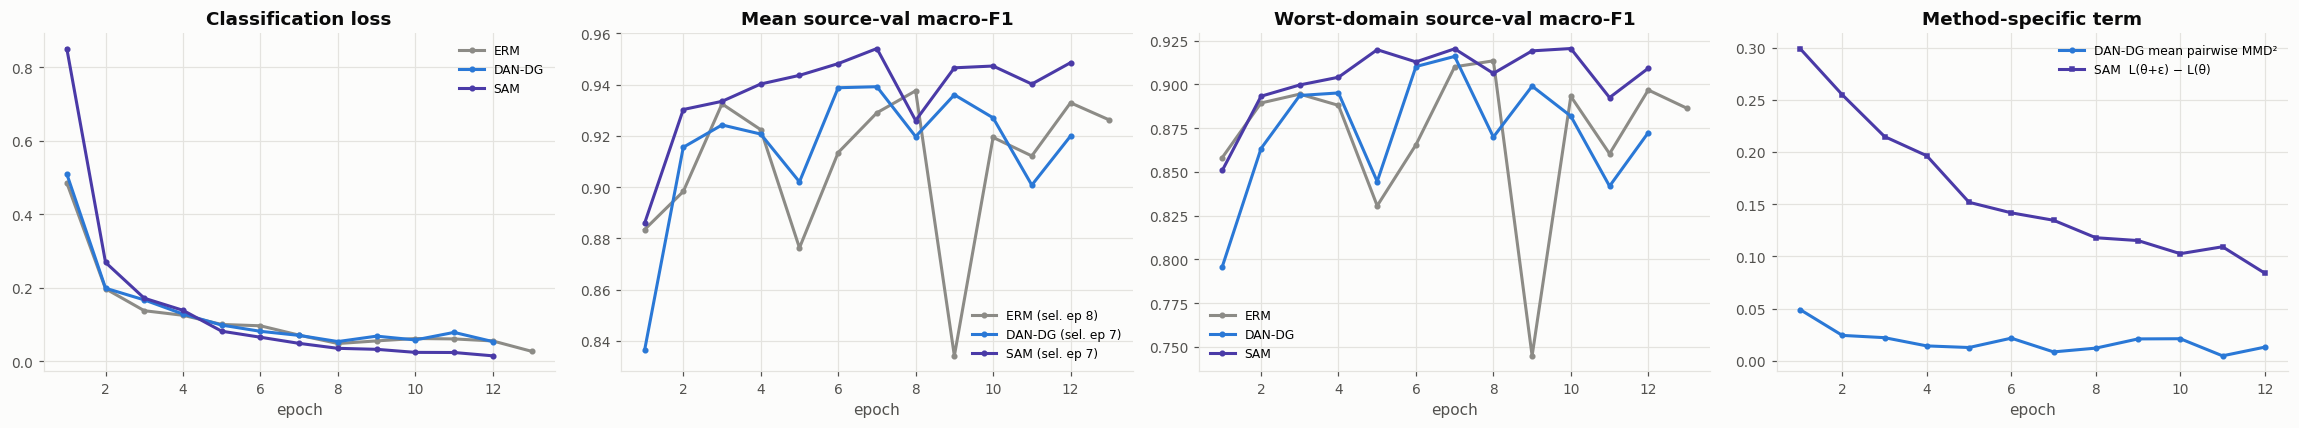

In [3]:
H = {'ERM': json.load(open(os.path.join(T2, 'checkpoints', 'source_only_history.json'))),
     'DAN-DG': json.load(open(os.path.join(CKPT, 'dan_dg_history.json'))), 'SAM': json.load(open(os.path.join(CKPT, 'sam_history.json')))}
fig, ax = plt.subplots(1, 4, figsize=(21, 4))
for n, meta in H.items():
    h = meta['history']; e = np.arange(1, len(h['cls_loss']) + 1); c = color_of(n)
    ax[0].plot(e, h['cls_loss'], 'o-', ms=3, color=c, label=n)
    ax[1].plot(e, h['val_mean_f1'], 'o-', ms=3, color=c, label=f'{n} (sel. ep {meta["best_epoch"]})')
    worst = h.get('val_worst_f1') or np.min([h['val_per_domain'][d]['f1'] for d in PACS_SOURCE_DOMAINS], 0)
    ax[2].plot(e, worst, 'o-', ms=3, color=c, label=n)
    if n == 'DAN-DG': ax[3].plot(e, h['mmd_loss'], 'o-', ms=3, color=c, label='DAN-DG mean pairwise MMD²')
    if n == 'SAM': ax[3].plot(e, np.array(h['sam_perturbed_loss']) - np.array(h['cls_loss']), 's-', ms=3, color=c, label='SAM  L(θ+ε) − L(θ)')
for a, t in zip(ax, ['Classification loss', 'Mean source-val macro-F1', 'Worst-domain source-val macro-F1', 'Method-specific term']):
    a.set_title(t); a.set_xlabel('epoch'); a.legend(fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_training_curves_all.png'))

### Local loss profile along the normalised gradient direction
The sharpness proxy is a single point (r = 0.05) on this curve. Plotting $L_{\text{val}}(\theta+r\,g/\|g\|)$ for r ∈ [0, 0.15] on the same fixed batch shows how quickly each model's loss rises. This is a local, direction-specific view, not a global flatness measure.

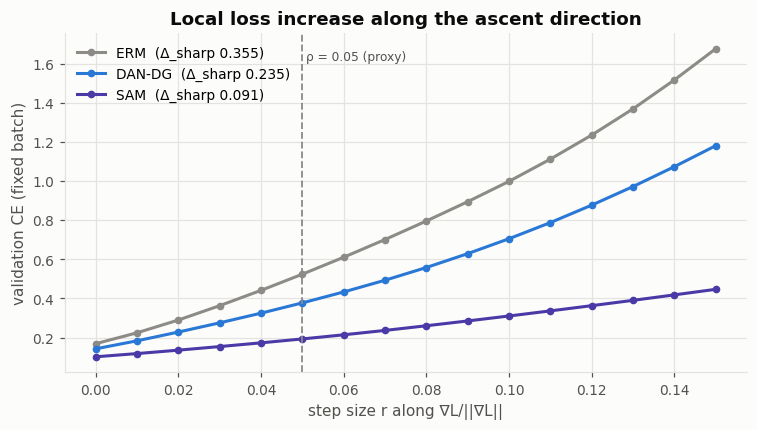

In [4]:
def loss_profile(net, radii):
    ce = nn.CrossEntropyLoss(); net.eval(); params = [p for p in net.parameters() if p.requires_grad]
    net.zero_grad(set_to_none=True); ce(net(xb)[0], yb).backward()
    g = [p.grad.detach().clone() for p in params]; gn = torch.norm(torch.stack([x.norm() for x in g]))
    out = []
    saved = [p.detach().clone() for p in params]
    with torch.no_grad():
        for r in radii:
            for p, gi in zip(params, g): p.add_(r * gi / gn)
            out.append(ce(net(xb)[0], yb).item())
            for p, s in zip(params, saved): p.copy_(s)     # exact restore (float32 add/sub is not exact)
    net.zero_grad(set_to_none=True); return out
radii = np.linspace(0, 0.15, 16)
fig, a = plt.subplots(figsize=(8, 4))
for n, net in nets.items():
    a.plot(radii, loss_profile(net, radii), 'o-', ms=4, color=color_of(n), label=f"{n}  (Δ_sharp {diag[n]['delta_sharp']:.3f})")
a.axvline(0.05, color=NEUTRAL, ls='--', lw=1.2); a.text(0.051, a.get_ylim()[1] * 0.95, 'ρ = 0.05 (proxy)', fontsize=8, color=INK_2, va='top')
a.set_xlabel('step size r along ∇L/||∇L||'); a.set_ylabel('validation CE (fixed batch)'); a.set_title('Local loss increase along the ascent direction'); a.legend()
save_show(fig, os.path.join(RES, 'task3_sharpness_profile.png'))

## 2. Final Sketch evaluation (all Task 3 decisions are fixed above)

In [5]:
sketch = PACSDataset(DATA, 'sketch', EVAL_TRANSFORM)
sk_loader = torch.utils.data.DataLoader(sketch, batch_size=64, shuffle=False)
sk_out = {n: collect_outputs(net, sk_loader, device) for n, net in nets.items()}
y_t = sk_out['ERM'][2]
rows = []
for n in MODELS:
    r = {'Model': n}
    for d in PACS_SOURCE_DOMAINS:
        lg, _, y = src_out[n][d]; r[f'{d} acc'] = 100 * (lg.argmax(1) == y).mean(); r[f'{d} F1'] = 100 * f1_score(y, lg.argmax(1), average='macro')
    r['mean src acc'] = np.mean([r[f'{d} acc'] for d in PACS_SOURCE_DOMAINS]); r['worst src acc'] = min(r[f'{d} acc'] for d in PACS_SOURCE_DOMAINS)
    r['mean src F1'] = np.mean([r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS]); r['worst src F1'] = min(r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS)
    r['Sketch acc'] = 100 * (sk_out[n][0].argmax(1) == y_t).mean(); r['Sketch F1'] = 100 * f1_score(y_t, sk_out[n][0].argmax(1), average='macro')
    r['source separability'] = diag[n]['source separability']; r['Δ_sharp'] = diag[n]['delta_sharp']
    rows.append(r)
table = pd.DataFrame(rows).set_index('Model')
table.insert(table.columns.get_loc('Sketch F1') + 1, 'Δ Sketch acc vs ERM', table['Sketch acc'] - table.loc['ERM', 'Sketch acc'])
table.to_csv(os.path.join(RES, 'task3_main_table.csv'))
table.round(3)

,photo acc,photo F1,art_painting acc,art_painting F1,cartoon acc,cartoon F1,mean src acc,worst src acc,mean src F1,worst src F1,Sketch acc,Sketch F1,Δ Sketch acc vs ERM,source separability,Δ_sharp
Model,,,,,,,,,,,,,,,
ERM,96.707,96.285,91.463,91.345,93.177,93.642,93.782,91.463,93.758,91.345,59.226,66.064,0.000,89.701,0.355
DAN-DG,97.305,97.081,91.220,91.598,92.537,93.071,93.687,91.220,93.916,91.598,69.000,70.363,9.773,70.100,0.235
SAM,97.605,97.154,92.195,92.032,96.588,97.035,95.463,92.195,95.407,92.032,68.287,67.031,9.061,88.372,0.091


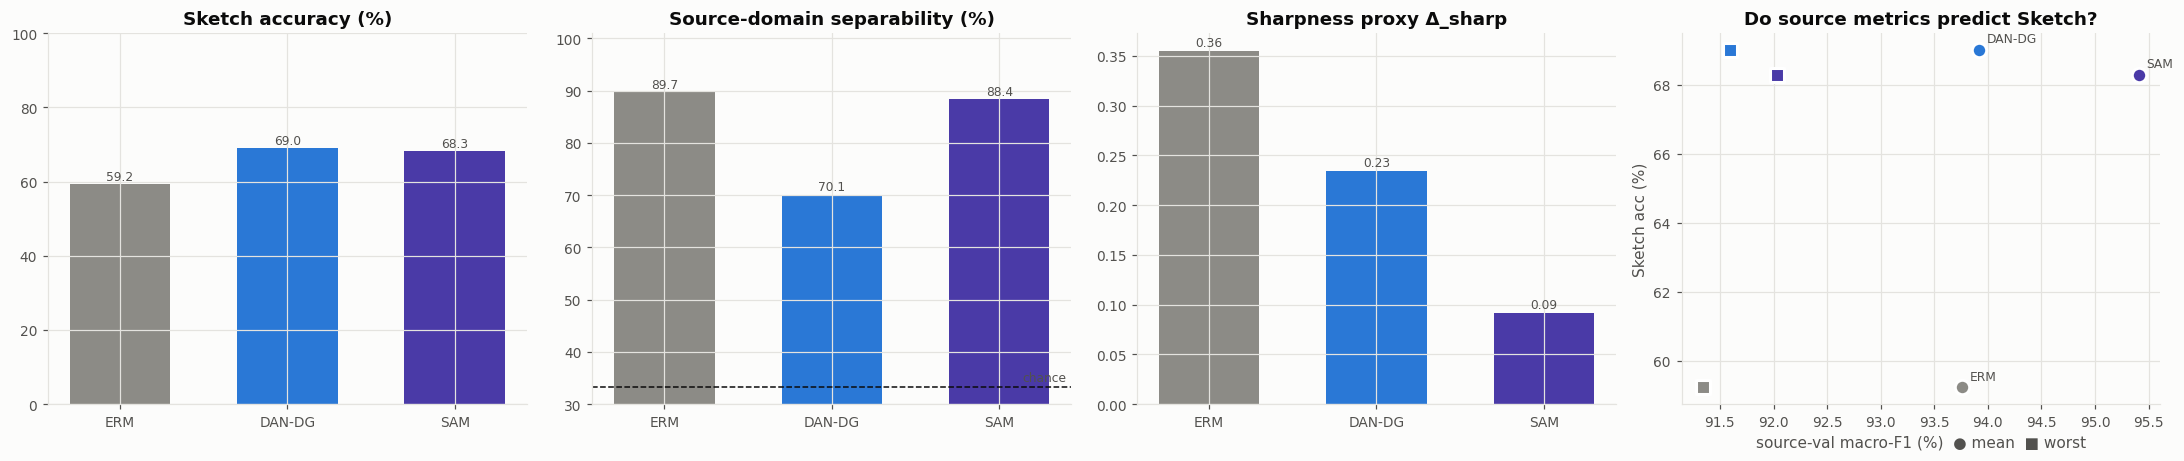

In [6]:
names = list(table.index); x = np.arange(3); cols = [color_of(n) for n in names]
fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
for a, col, title, lim in [(ax[0], 'Sketch acc', 'Sketch accuracy (%)', (0, 100)), (ax[1], 'source separability', 'Source-domain separability (%)', (30, 101)),
                           (ax[2], 'Δ_sharp', 'Sharpness proxy Δ_sharp', None)]:
    b = a.bar(x, table[col], 0.6, color=cols); bar_labels(a, b, fmt='{:.2f}' if col == 'Δ_sharp' else '{:.1f}', offset=0.3 if col != 'Δ_sharp' else 0.002)
    a.set_xticks(x); a.set_xticklabels(names); a.set_title(title)
    if lim: a.set_ylim(*lim)
ax[1].axhline(100 / 3, color='#0b0b0b', ls='--', lw=1); ax[1].text(2.4, 34.5, 'chance', ha='right', fontsize=8, color=INK_2)
for n in names:
    ax[3].scatter(table.loc[n, 'mean src F1'], table.loc[n, 'Sketch acc'], s=90, color=color_of(n), marker='o', edgecolor='white', linewidth=2, zorder=3)
    ax[3].scatter(table.loc[n, 'worst src F1'], table.loc[n, 'Sketch acc'], s=90, color=color_of(n), marker='s', edgecolor='white', linewidth=2, zorder=3)
    ax[3].annotate(n, (table.loc[n, 'mean src F1'], table.loc[n, 'Sketch acc']), xytext=(5, 5), textcoords='offset points', fontsize=8, color=INK_2)
ax[3].set_xlabel('source-val macro-F1 (%)  ● mean  ■ worst'); ax[3].set_ylabel('Sketch acc (%)'); ax[3].set_title('Do source metrics predict Sketch?')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_summary.png'))

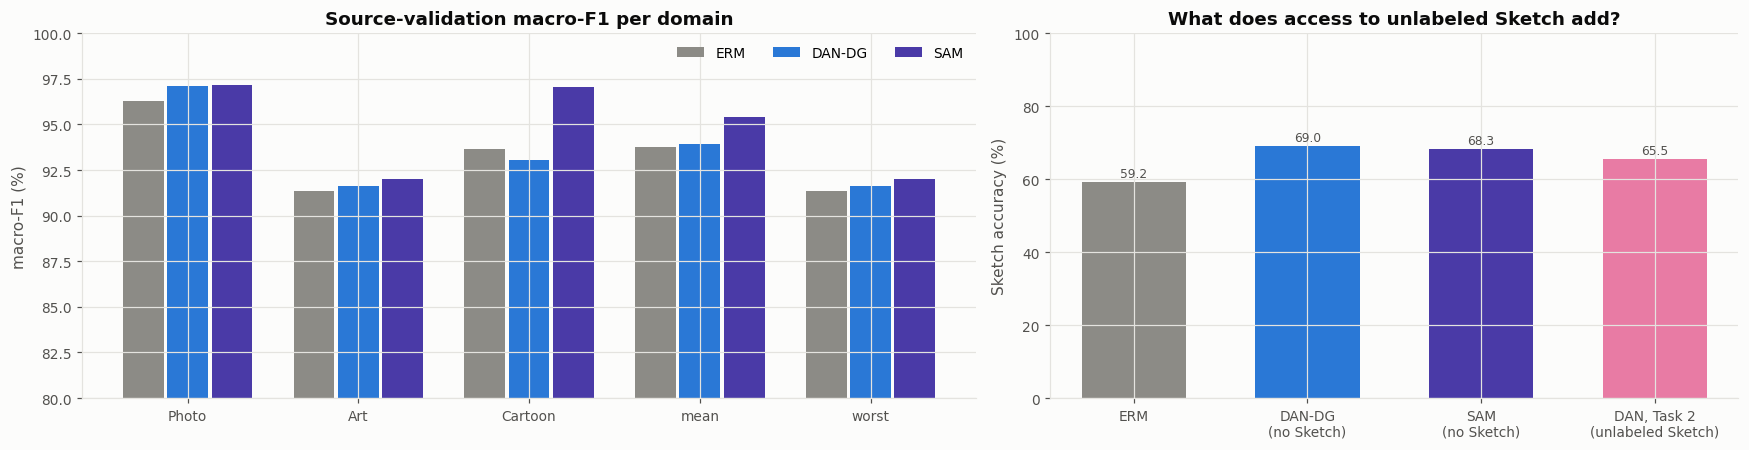

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1.3, 1]})
w = 0.26
for i, n in enumerate(names):
    vals = [table.loc[n, f'{d} F1'] for d in PACS_SOURCE_DOMAINS] + [table.loc[n, 'mean src F1'], table.loc[n, 'worst src F1']]
    a1.bar(np.arange(5) + (i - 1) * w, vals, w * 0.92, color=color_of(n), label=n)
a1.set_xticks(range(5)); a1.set_xticklabels(['Photo', 'Art', 'Cartoon', 'mean', 'worst']); a1.set_ylim(80, 100)
a1.set_ylabel('macro-F1 (%)'); a1.set_title('Source-validation macro-F1 per domain'); a1.legend(ncol=3)
cmp = {'ERM': table.loc['ERM', 'Sketch acc'], 'DAN-DG\n(no Sketch)': table.loc['DAN-DG', 'Sketch acc'], 'SAM\n(no Sketch)': table.loc['SAM', 'Sketch acc']}
cols = [color_of('ERM'), color_of('DAN-DG'), color_of('SAM')]
if T2_READY:
    t2 = pd.read_csv(T2_MAIN, index_col=0); cmp['DAN, Task 2\n(unlabeled Sketch)'] = t2.loc['DAN', 'Sketch acc']; cols.append(PALETTE[4])
cmp = pd.Series(cmp)
b = a2.bar(cmp.index, cmp.values, 0.6, color=cols); bar_labels(a2, b)
a2.set_ylim(0, 100); a2.set_ylabel('Sketch accuracy (%)'); a2.set_title('What does access to unlabeled Sketch add?')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_source_domains_and_task2_comparison.png'))

## 3. Per-class Sketch changes vs ERM, and comparison with Task 2
Task 2 per-class Sketch accuracies are read from `task2_domain_adaptation/results/task2_per_class_target.csv` if it exists (produced by Task 2 notebook 5; skipped otherwise). That file is used only for this *final* comparison, never to change a Task 3 setting.

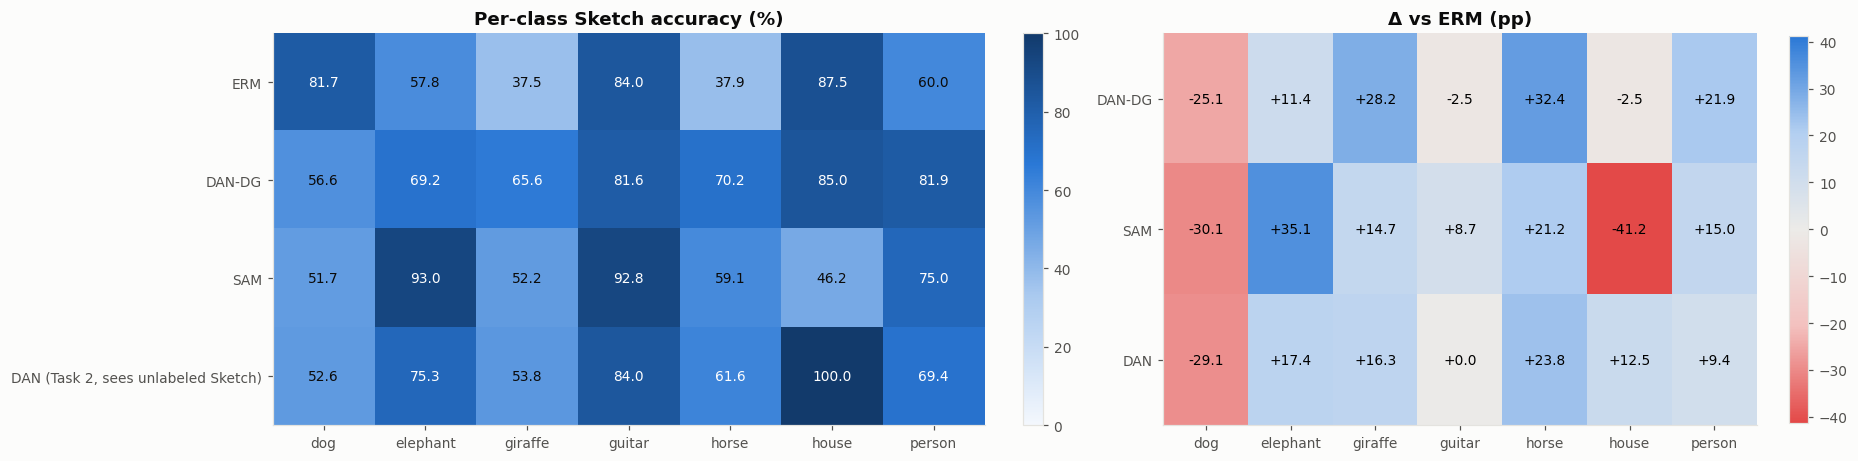

In [8]:
pc = pd.DataFrame({n: [100 * (sk_out[n][0].argmax(1)[y_t == c] == c).mean() for c in range(7)] for n in names}, index=PACS_CLASSES)
if T2_READY:
    t2pc = pd.read_csv(T2_PC, index_col=0)
    assert np.allclose(t2pc['Source-only'].values, pc['ERM'].values, atol=0.1), 'ERM and Task 2 Source-only must be the same checkpoint'
    pc['DAN (Task 2, sees unlabeled Sketch)'] = t2pc['DAN']
delta = pc.drop(columns='ERM').sub(pc['ERM'], axis=0)
pc.to_csv(os.path.join(RES, 'task3_per_class_sketch.csv')); delta.to_csv(os.path.join(RES, 'task3_per_class_delta.csv'))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 4.3), gridspec_kw={'width_ratios': [1.2, 1]})
im = a1.imshow(pc.T.values, cmap=SEQ_CMAP, vmin=0, vmax=100, aspect='auto')
for i in range(pc.shape[1]):
    for j in range(7): v = pc.T.values[i, j]; a1.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9, color='white' if v > 60 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES); a1.set_yticks(range(pc.shape[1])); a1.set_yticklabels(pc.columns); a1.grid(False)
a1.set_title('Per-class Sketch accuracy (%)'); fig.colorbar(im, ax=a1, fraction=0.03)
lim = max(10, np.abs(delta.values).max())
im = a2.imshow(delta.T.values, cmap=DIV_CMAP, vmin=-lim, vmax=lim, aspect='auto')
for i in range(delta.shape[1]):
    for j in range(7): a2.text(j, i, f'{delta.T.values[i, j]:+.1f}', ha='center', va='center', fontsize=9)
a2.set_xticks(range(7)); a2.set_xticklabels(PACS_CLASSES); a2.set_yticks(range(delta.shape[1])); a2.set_yticklabels([c.split(' (')[0] for c in delta.columns]); a2.grid(False)
a2.set_title('Δ vs ERM (pp)'); fig.colorbar(im, ax=a2, fraction=0.03)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_per_class_transfer.png'))

In [9]:
rows = []
cm0 = confusion_matrix(y_t, sk_out['ERM'][0].argmax(1), labels=range(7)); cmn0 = cm0 / cm0.sum(1, keepdims=True)
for n in ['DAN-DG', 'SAM']:
    cm = confusion_matrix(y_t, sk_out[n][0].argmax(1), labels=range(7)); cmn = cm / cm.sum(1, keepdims=True)
    for kind, cls in [('largest gain', delta[n].idxmax()), ('largest drop', delta[n].idxmin())]:
        c = PACS_CLASSES.index(cls); o = cmn[c].copy(); o[c] = -1; j = o.argmax(); o0 = cmn0[c].copy(); o0[c] = -1; j0 = o0.argmax()
        rows.append({'model': n, 'kind': kind, 'class': cls, 'Δ acc (pp)': delta.loc[cls, n],
                     'dominant confusion (model)': f'{PACS_CLASSES[j]} ({cmn[c, j]:.2f})', 'dominant confusion (ERM)': f'{PACS_CLASSES[j0]} ({cmn0[c, j0]:.2f})'})
pd.DataFrame(rows).set_index(['model', 'kind']).round(2)

class  Δ acc (pp) dominant confusion (model)  \
model  kind                                                            
DAN-DG largest gain     horse       32.35                 dog (0.12)   
       largest drop       dog      -25.13              person (0.22)   
SAM    largest gain  elephant       35.14                 dog (0.05)   
       largest drop     house      -41.25            elephant (0.42)   

                    dominant confusion (ERM)  
model  kind                                   
DAN-DG largest gain               dog (0.52)  
       largest drop          elephant (0.13)  
SAM    largest gain               dog (0.42)  
       largest drop          elephant (0.10)

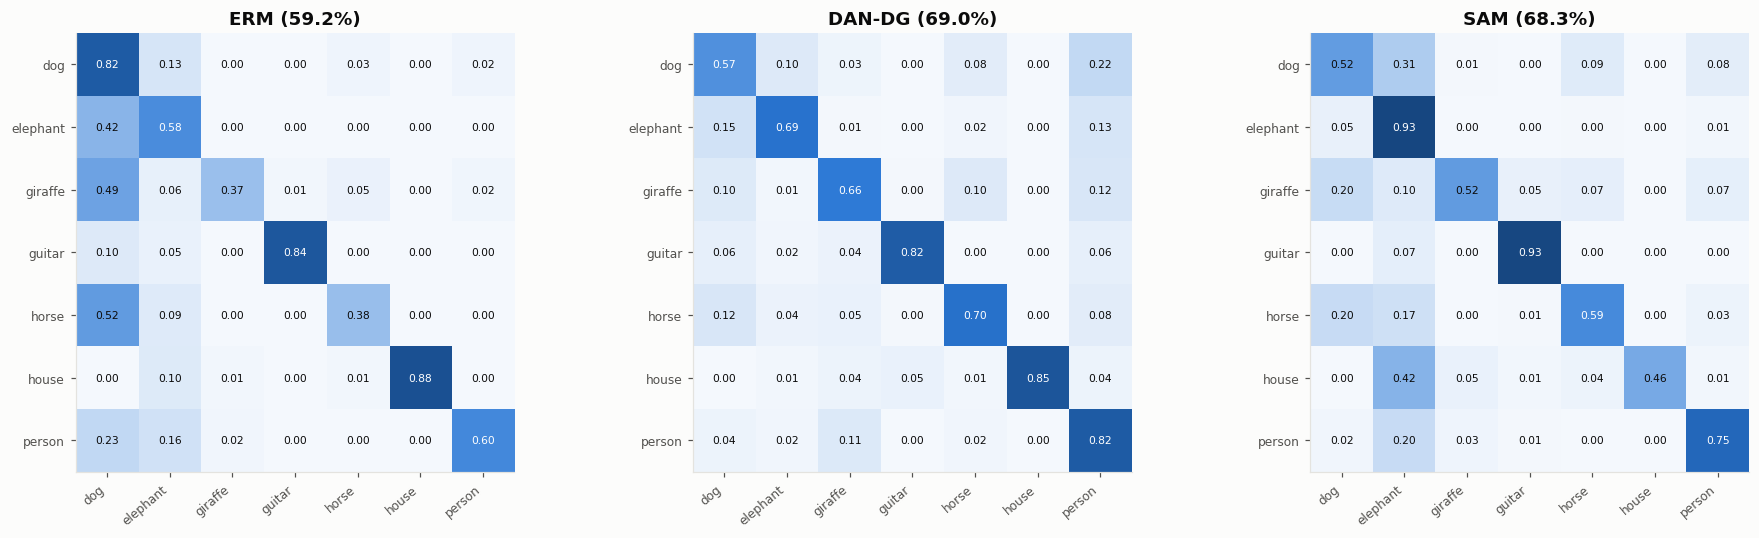

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, n in zip(axes, names):
    cm = confusion_matrix(y_t, sk_out[n][0].argmax(1), labels=range(7)); cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap=SEQ_CMAP, vmin=0, vmax=1)
    for i in range(7):
        for j in range(7): ax.text(j, i, f'{cmn[i, j]:.2f}', ha='center', va='center', fontsize=7, color='white' if cmn[i, j] > 0.55 else '#0b0b0b')
    ax.set_xticks(range(7)); ax.set_xticklabels(PACS_CLASSES, rotation=40, ha='right', fontsize=8); ax.set_yticks(range(7)); ax.set_yticklabels(PACS_CLASSES, fontsize=8); ax.grid(False)
    ax.set_title(f"{n} ({table.loc[n, 'Sketch acc']:.1f}%)")
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_confusion_matrices.png'))

### Same sketch, three models
One random Sketch image per class (seed 6304) with the prediction of each model (✓ correct, ✗ wrong) and its confidence.

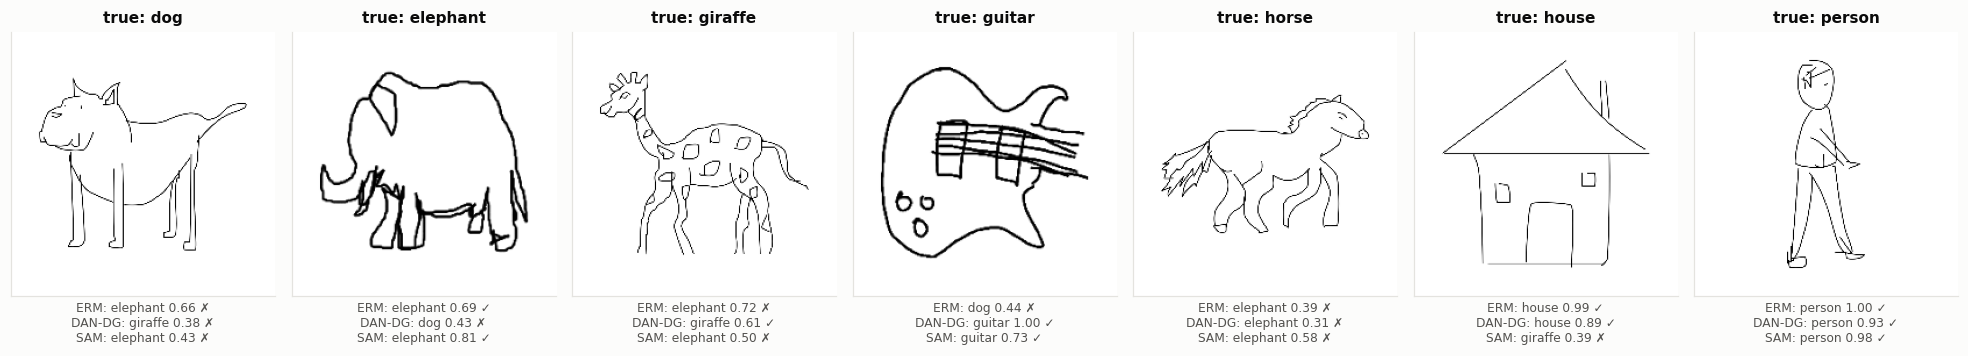

In [11]:
raw = PACSDataset(DATA, 'sketch'); rng = np.random.RandomState(SEED)
probs = {n: torch.softmax(torch.tensor(sk_out[n][0]), 1).numpy() for n in names}
fig, axes = plt.subplots(1, 7, figsize=(18, 4.4))
for c, ax in enumerate(axes):
    i = int(rng.choice(np.where(y_t == c)[0])); ax.imshow(raw[i][0]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    lines = [f"{n}: {PACS_CLASSES[probs[n][i].argmax()]} {probs[n][i].max():.2f} {'✓' if probs[n][i].argmax() == c else '✗'}" for n in names]
    ax.set_title(f'true: {PACS_CLASSES[c]}', fontsize=10); ax.set_xlabel('\n'.join(lines), fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_same_sketch_three_models.png'))

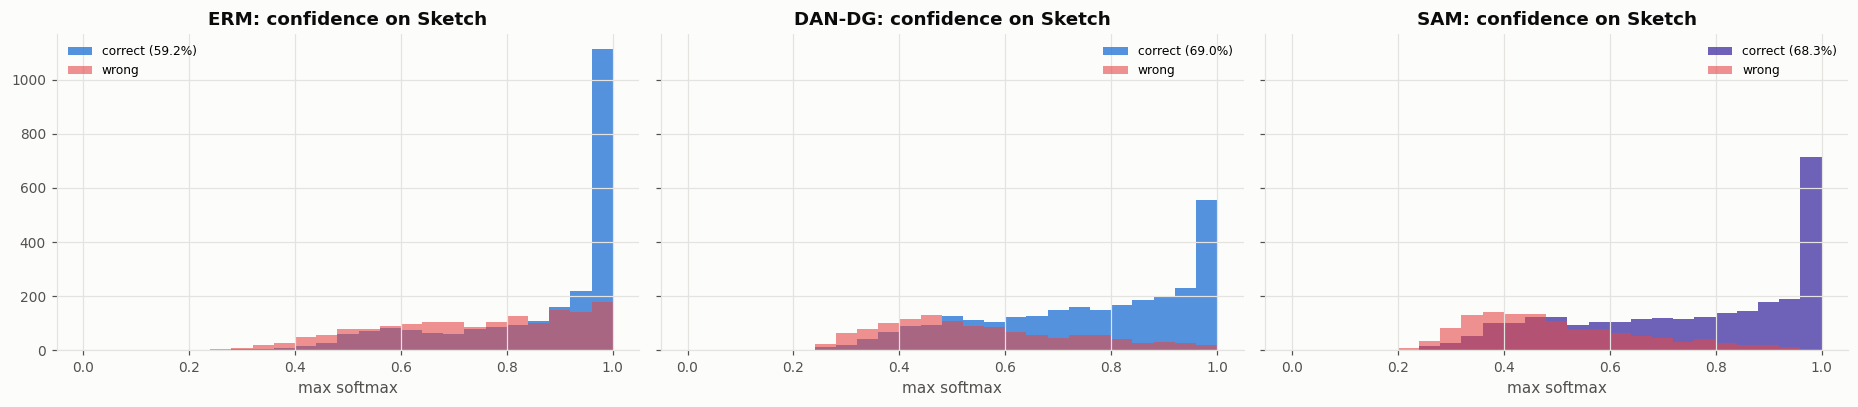

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 3.8), sharey=True)
bins = np.linspace(0, 1, 26)
for ax, n in zip(axes, names):
    conf = probs[n].max(1); ok = probs[n].argmax(1) == y_t
    ax.hist(conf[ok], bins=bins, color=color_of(n) if n != 'ERM' else PALETTE[0], alpha=0.8, label=f'correct ({ok.mean()*100:.1f}%)')
    ax.hist(conf[~ok], bins=bins, color=PALETTE[7], alpha=0.6, label='wrong')
    ax.set_title(f'{n}: confidence on Sketch'); ax.set_xlabel('max softmax'); ax.legend(fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_sketch_confidence.png'))

## 4. Failures
Sketches that ERM classified correctly but the DG method broke, and the reverse (seed 6304).

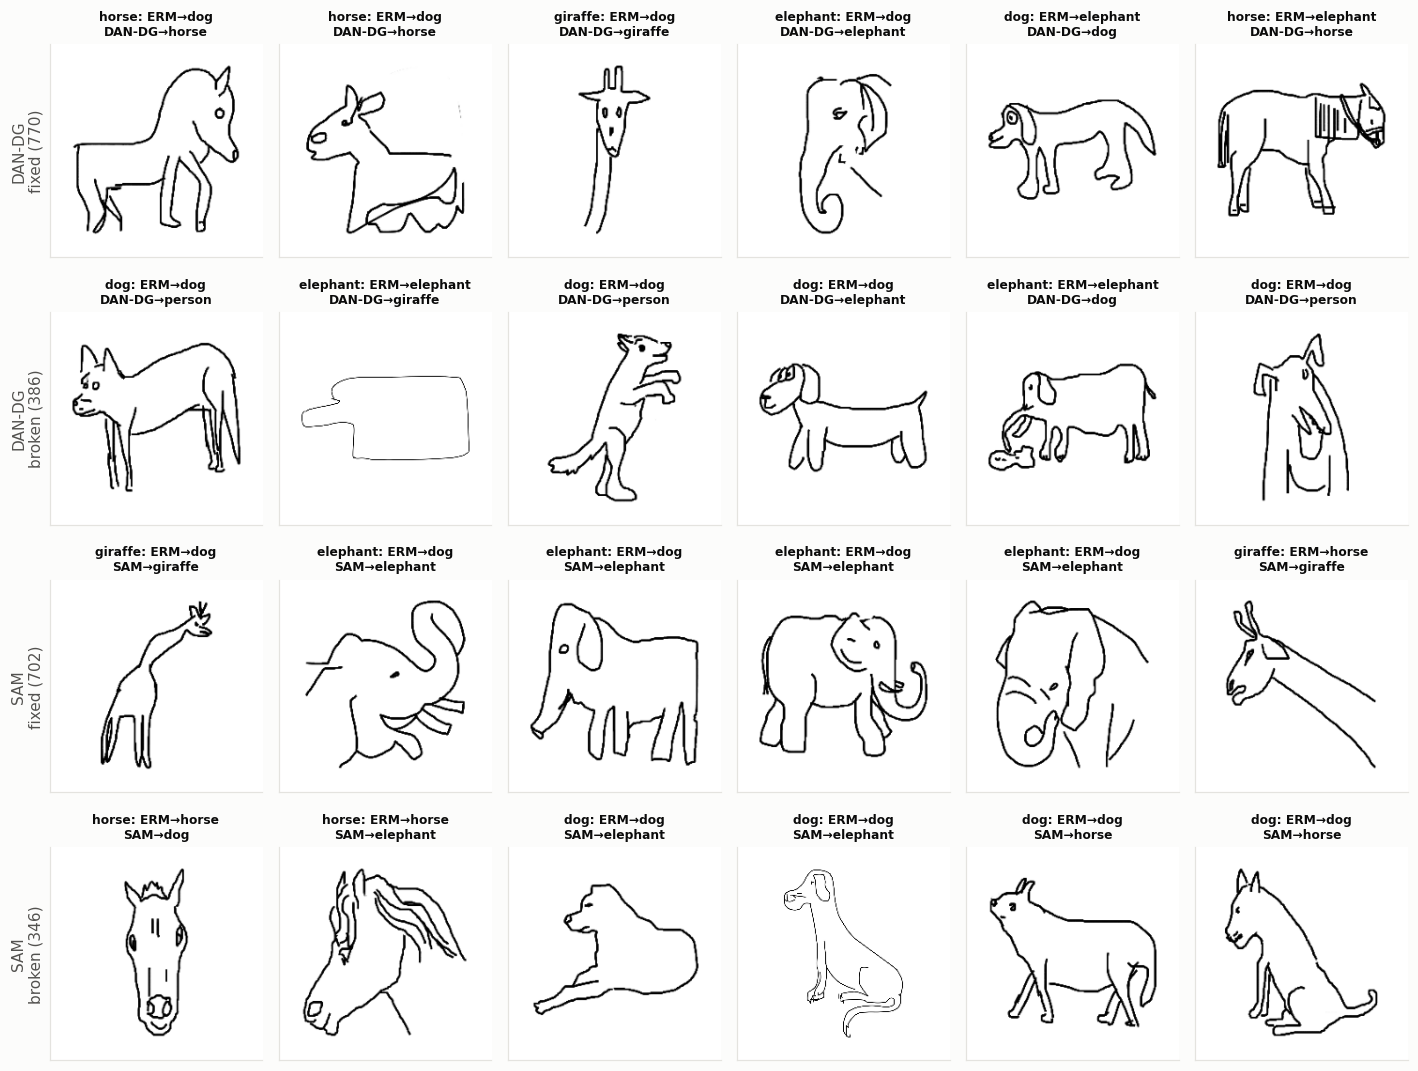

In [13]:
raw = PACSDataset(DATA, 'sketch'); p0 = sk_out['ERM'][0].argmax(1); rng = np.random.RandomState(SEED)
fig, axes = plt.subplots(4, 6, figsize=(13, 10))
for r, n in enumerate(['DAN-DG', 'SAM']):
    pn = sk_out[n][0].argmax(1)
    for k, (pool, tag) in enumerate([(np.where((p0 != y_t) & (pn == y_t))[0], 'fixed'), (np.where((p0 == y_t) & (pn != y_t))[0], 'broken')]):
        pick = rng.choice(pool, min(6, len(pool)), replace=False) if len(pool) else []
        for c in range(6):
            ax = axes[2 * r + k, c]; ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if c < len(pick):
                i = int(pick[c]); ax.imshow(raw[i][0]); ax.set_title(f'{PACS_CLASSES[y_t[i]]}: ERM→{PACS_CLASSES[p0[i]]}\n{n}→{PACS_CLASSES[pn[i]]}', fontsize=8)
        axes[2 * r + k, 0].set_ylabel(f'{n}\n{tag} ({len(pool)})')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_transfer_examples.png'))

## 5. Feature geometry: source domains and Sketch
One t-SNE per model (perplexity 30, PCA init, seed 6304) on 300 validation features per source domain plus 300 Sketch features. Top row: colour = domain, showing whether the sources overlap (invariance) and where the unseen Sketch domain lands. Bottom row: the same embedding coloured by class, showing whether Sketch images land in the right class clusters. Coordinates are not comparable across panels.

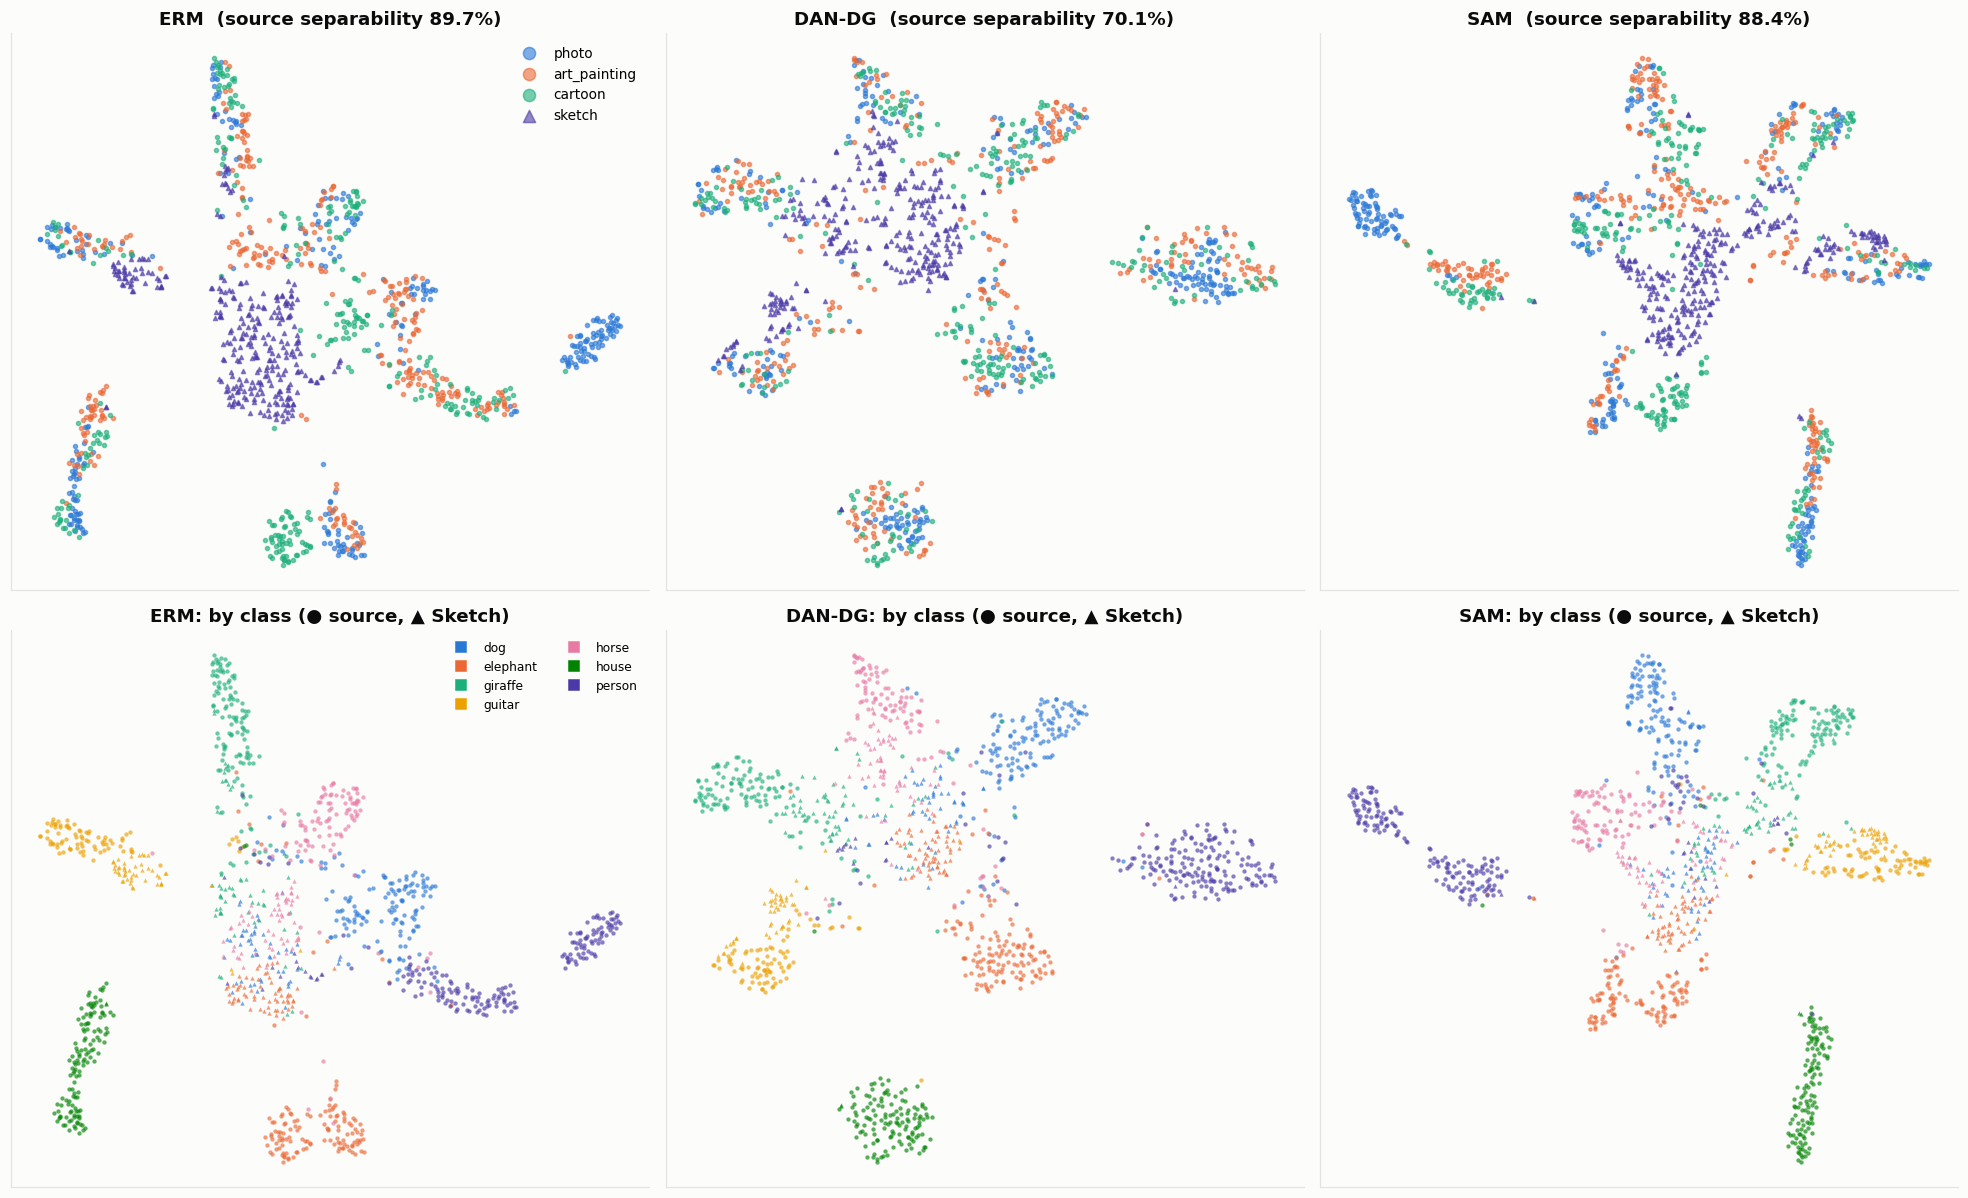

In [14]:
fig, axes2 = plt.subplots(2, 3, figsize=(18, 11))
axes = axes2[0]
for ax, n in zip(axes, names):
    rng = np.random.RandomState(SEED); X, D, Ys = [], [], []
    for d in PACS_SOURCE_DOMAINS:
        f = src_out[n][d][1]; i = rng.choice(len(f), 300, replace=False); X.append(f[i]); D += [d] * 300; Ys.append(src_out[n][d][2][i])
    i = rng.choice(len(sk_out[n][1]), 300, replace=False); X.append(sk_out[n][1][i]); D += ['sketch'] * 300; Ys.append(sk_out[n][2][i])
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(np.concatenate(X)); D = np.array(D)
    for d in PACS_SOURCE_DOMAINS + ['sketch']:
        ax.scatter(E[D == d, 0], E[D == d, 1], s=7, alpha=0.6, color=DOMAIN_COLORS[d], label=d, marker='^' if d == 'sketch' else 'o')
    ax.set_title(f"{n}  (source separability {table.loc[n, 'source separability']:.1f}%)"); ax.set_xticks([]); ax.set_yticks([])
    Yc = np.concatenate(Ys)
    bx = axes2[1, list(names).index(n)]
    for c in range(7):
        for mk, dm in [('o', D != 'sketch'), ('^', D == 'sketch')]:
            s_ = (Yc == c) & dm; bx.scatter(E[s_, 0], E[s_, 1], s=8, marker=mk, alpha=0.65, color=PALETTE[c], linewidths=0)
    bx.set_title(f'{n}: by class (● source, ▲ Sketch)'); bx.set_xticks([]); bx.set_yticks([])
axes[0].legend(markerscale=3)
axes2[1, 0].legend(handles=[Line2D([], [], ls='', marker='s', color=PALETTE[c], label=PACS_CLASSES[c]) for c in range(7)], fontsize=8, ncol=2)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_tsne_domains.png'))

## 6. Evidence for Research Questions 1–4
Facts only; interpretation belongs in the report.

In [15]:
t2 = pd.read_csv(T2_MAIN, index_col=0) if T2_READY else None
print('RQ1 source metrics vs Sketch:')
for n in names:
    print(f"  {n:7s} mean src F1 {table.loc[n, 'mean src F1']:.2f} | worst src F1 {table.loc[n, 'worst src F1']:.2f} | Sketch acc {table.loc[n, 'Sketch acc']:.2f}")
print('  weakest Sketch classes (ERM):', pc['ERM'].nsmallest(3).round(1).to_dict())
print('RQ2 DAN-DG: source separability', f"{table.loc['ERM', 'source separability']:.1f} -> {table.loc['DAN-DG', 'source separability']:.1f}",
      '| Δ Sketch', f"{table.loc['DAN-DG', 'Δ Sketch acc vs ERM']:+.2f}", '| classes that dropped:', list(delta.index[delta['DAN-DG'] < 0]))
print('RQ3 sharpness ranking (low→high):', table['Δ_sharp'].sort_values().index.tolist(), '| Sketch ranking (high→low):', table['Sketch acc'].sort_values(ascending=False).index.tolist())
print('RQ4 target access: ERM', f"{table.loc['ERM', 'Sketch acc']:.2f}", '| DAN-DG (no Sketch)', f"{table.loc['DAN-DG', 'Sketch acc']:.2f}",
      '| DAN (Task 2, unlabeled Sketch)', f"{t2.loc['DAN', 'Sketch acc']:.2f}" if T2_READY else 'n/a (run Task 2 notebook 5)')

RQ1 source metrics vs Sketch:
  ERM     mean src F1 93.76 | worst src F1 91.35 | Sketch acc 59.23
  DAN-DG  mean src F1 93.92 | worst src F1 91.60 | Sketch acc 69.00
  SAM     mean src F1 95.41 | worst src F1 92.03 | Sketch acc 68.29
  weakest Sketch classes (ERM): {'giraffe': 37.5, 'horse': 37.9, 'elephant': 57.8}
RQ2 DAN-DG: source separability 89.7 -> 70.1 | Δ Sketch +9.77 | classes that dropped: ['dog', 'guitar', 'house']
RQ3 sharpness ranking (low→high): ['SAM', 'DAN-DG', 'ERM'] | Sketch ranking (high→low): ['DAN-DG', 'SAM', 'ERM']
RQ4 target access: ERM 59.23 | DAN-DG (no Sketch) 69.00 | DAN (Task 2, unlabeled Sketch) 65.49
